In [1]:
from PIL import Image
import numpy as np
import math
import matplotlib.pyplot as plt

### Getting Pixel RGB Values From Square $n \times n$ Image

In [2]:
im = Image.open("/Users/devaldeliwala/desktop/test.png", 'r')
imrgb = im.convert("RGB")
pixel_values = np.array(list(imrgb.getdata()))/255

/opt/homebrew/lib/python3.11/site-packages/PIL/Image.py:992: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


### Assigning Pixels to Points on a Unit Sphere
---

The code segment below first equally distributes points along a unit sphere using the [Fibonacci Sphere Algorithm](https://arxiv.org/pdf/0912.4540.pdf). The # of points distributted is equivalent to the amount of pixels in an image. 

After the points are distributted I assign pixel RGB values to each point on the sphere. The Top-Left-most pixel on the image is assigned to point $(0, 1, 0)$. Each pixel is read left to right & top to bottom and are continouslly assigned to points decreasing in $y$ value


This image is 48 x 48 : 2304 total pixels 


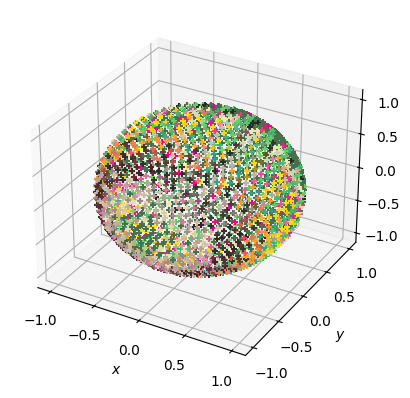

In [6]:
im = np.array(Image.open("/Users/devaldeliwala/desktop/test.png"))
        
n_pixels_width = im.shape[0]
n_pixels = n_pixels_width**2

print(f"This image is {n_pixels_width} x {n_pixels_width} : {n_pixels} total pixels ")

points = []
phi = math.pi * (math.sqrt(5) - 1)          # golden angle

for i in range(n_pixels): 
    y = 1 - (i / float(n_pixels - 1)) * 2   # y goes from 1 to -1
    radius = math.sqrt(1 - y * y)           # radius at y

    theta = phi * i                         # golden angle increment

    x = math.cos(theta) * radius 
    z = math.sin(theta) * radius 

    points.append((x, y, z))
    
pixel_points = np.array([
    [points[0], pixel_values[0]]
])

for i in range(len(points)-1): 
    pixel_points = np.append(pixel_points, [[points[i+1], pixel_values[i+1]]], axis = 0)

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

for i in range(len(points)):
    ax.scatter(pixel_points[i][0][0], 
               pixel_points[i][0][1],
               pixel_points[i][0][2],
               c = pixel_points[i][1].reshape(1, -1),
               marker = '+'
    )
    
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

plt.show()

### Recreates Image from Pixel Positions & RGB Values on Bloch Sphere

In [9]:
im = Image.open('/Users/devaldeliwala/desktop/test.png', 'r')
im = im.convert("RGB")

rgb_list = np.array([pixel_points[0][1]*255])

for i in range(len(pixel_points)-1):
    rgb_list = np.append(rgb_list,
                         [pixel_points[i+1][1]*255],
                         axis = 0
                )

rgb_list = rgb_list.astype(int)
rgb_list = tuple(map(tuple, rgb_list))

image_final = Image.new(im.mode, im.size)
image_final.putdata(rgb_list)
image_final.save("output.png")

In [33]:
# check if pixel_points is y-decreasing
y_points = np.array([])

for i in pixel_points: 
    y_points = np.append(y_points, [i[0][1]], axis = 0)

y_check = np.sort(y_points)[::-1]

np.array_equal(y_points, y_check)

True